# 05 · Evaluate routing, omissions, and failure modes

**Question:** What actually happened on the held-out prose families, and what would block clinical use?

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
get_ipython().run_line_magic('matplotlib', 'inline')

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
DATA = ROOT / 'data/synthetic/transfer_requests.csv'
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})


## Evaluation provenance
Run `python scripts/build_project.py` before this notebook. All numbers below are loaded from that executed pipeline, not manually entered. Test families were excluded from fitting and hyperparameter selection; parser debugging used development test diagnostics, so this is not an untouched external evaluation.

In [2]:
metrics = json.loads((ROOT/'reports/metrics.json').read_text())
manifest = json.loads((ROOT/'artifacts/run_manifest.json').read_text())
display(manifest)
display(pd.DataFrame([{ 'approach':name, **{k:m[k] for k in ['accuracy','macro_precision','macro_recall','macro_f1','coverage','selective_accuracy','icu_false_positives','icu_false_negatives','icu_fn_abstentions']}} for name,m in metrics.items() if 'coverage' in m]))

{'seed': 20260909,
 'python': '3.12.4',
 'features': ['oxygen_support',
  'vasopressor_use',
  'monitoring_required',
  'specialty_need',
  'requested_service',
  'systolic_bp',
  'heart_rate',
  'spo2'],
 'packages': {'pandas': '2.3.3',
  'numpy': '2.5.3',
  'scikit-learn': '1.9.0',
  'streamlit': '1.63.0',
  'plotly': '6.9.0',
  'matplotlib': '3.11.1'},
 'split_counts': {'train': 625, 'test': 250, 'validation': 125},
 'selection': {'selected_depth': 6,
  'candidates': [{'max_depth': 3, 'validation_macro_f1': 0.9093425938038505},
   {'max_depth': 4, 'validation_macro_f1': 0.9838537287621417},
   {'max_depth': 5, 'validation_macro_f1': 0.9838537287621417},
   {'max_depth': 6, 'validation_macro_f1': 0.9921893775534727}]},
 'dataset_sha256': '3bde38cea1c0f06f5c211daecd6fc4fb9c7a9f587c38c4cb5e5a9f325739753c',
 'test_use': 'Excluded from fitting and hyperparameter selection; development test diagnostics informed parser bug fixes. Not independent external validation.',
 'simulation_caveat':

,approach,accuracy,macro_precision,macro_recall,macro_f1,coverage,selective_accuracy,icu_false_positives,icu_false_negatives,icu_fn_abstentions
0,rules,0.732,1.000000,0.706956,0.818470,0.732,1.000,0,2,2
1,decision_tree,0.976,0.974846,0.974266,0.974382,1.000,0.976,1,0,0
2,majority_baseline,0.328,0.082000,0.250000,0.123494,1.000,0.328,168,0,0


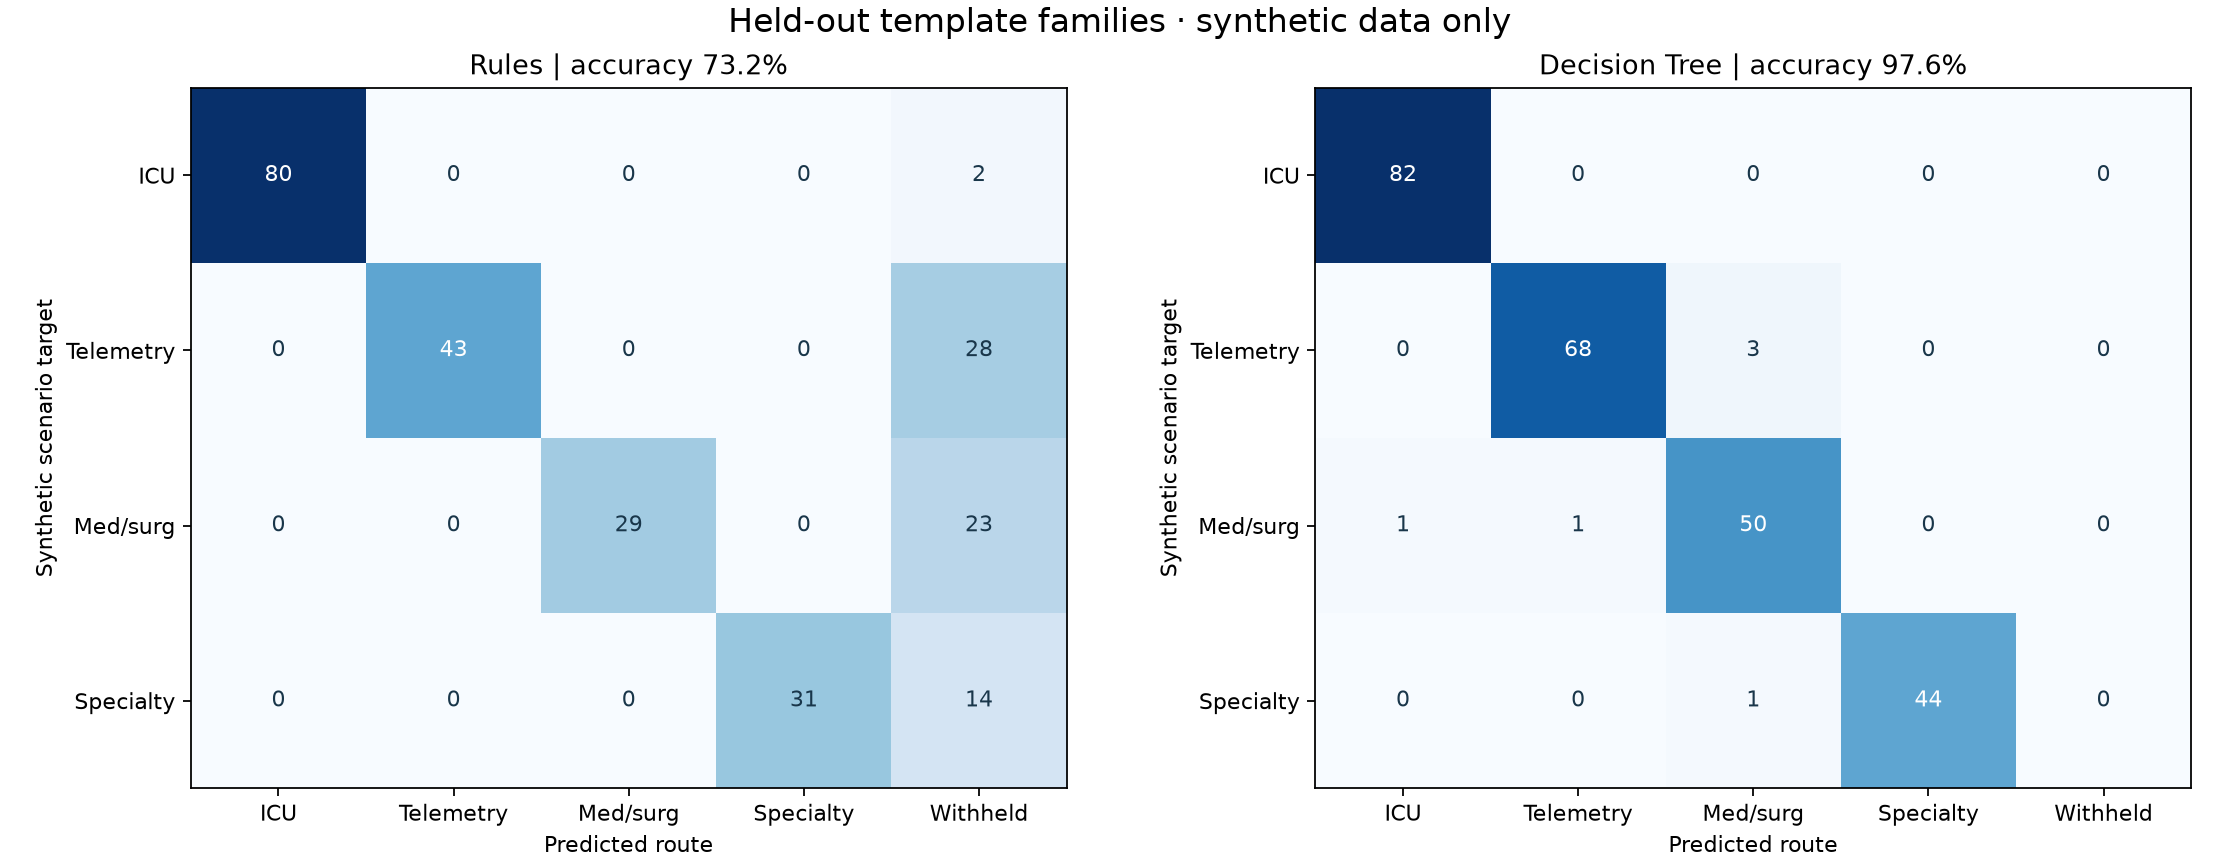

,precision,recall,f1-score,support
ICU,0.987952,1.000000,0.993939,82.000
telemetry,0.985507,0.957746,0.971429,71.000
medical/surgical,0.925926,0.961538,0.943396,52.000
specialty review,1.000000,0.977778,0.988764,45.000
accuracy,0.976000,0.976000,0.976000,0.976
macro avg,0.974846,0.974266,0.974382,250.000
weighted avg,0.976525,0.976000,0.976102,250.000


In [3]:
from IPython.display import Image
display(Image(filename=str(ROOT/'reports/figures/confusion_matrices.png')))
display(pd.DataFrame(metrics['decision_tree']['per_class']).T)

In [4]:
predictions = pd.read_csv(ROOT/'reports/test_predictions.csv')
failures = pd.read_csv(ROOT/'reports/failures.csv')
display(failures.groupby(['approach','failure_type']).size().rename('count').reset_index())
for row in failures.groupby(['approach','failure_type']).head(1).itertuples():
    print(f'\n{row.request_id} | {row.approach} | {row.expected} -> {row.predicted}')
    print(row.note)

,approach,failure_type,count
0,decision_tree,ICU false positive,1
1,decision_tree,route mismatch,5
2,rules,abstention,67



SYN-0007 | rules | telemetry -> insufficient information
SYNTHETIC TRAINING CASE. Referrer asks for telemetry bed. Timing: urgent. BP 113/70. Service needed: cardiology. Resp status: nasal cannula. Capacity status: available. Pt is 30 y/o. Needs tele. Currently on norepinephrine. No tertiary specialty assessment needed. Required isolation: none. Pulse 97. Referrer: Synthetic Prairie Hospital. Working diagnosis: heart failure. O2 sat 96%. No vasoactive infusion.

SYN-0071 | decision_tree | medical/surgical -> telemetry
SYNTHETIC TRAINING CASE. Referrer: Synthetic West Community. Pulse 61. No vasoactive infusion. Service needed: internal medicine. Pt is 25 y/o. O2 sat 99%. Timing: routine. Working diagnosis: pneumonia. Resp status: nasal cannula. BP 116/70. Capacity status: limited. No tertiary specialty assessment needed. Required isolation: contact.

SYN-0975 | decision_tree | medical/surgical -> ICU
SYNTHETIC TRAINING CASE. Timing: urgent. No vasoactive infusion. Working diagnosis: u

## ICU error definitions
An ICU false positive is any non-ICU scenario labeled ICU. A false negative is any ICU scenario not labeled ICU, including a withheld suggestion. The separate abstention count prevents conflating an intentional clarification request with lower-acuity routing. Neither error count measures actual patient harm in this fictional cohort.

In [5]:
display(pd.read_csv(ROOT/'reports/extraction_metrics.csv'))
display(metrics['missing_information'])
display(pd.read_csv(ROOT/'reports/subgroups.csv'))
display(json.loads((ROOT/'reports/challenge_summary.json').read_text()))
challenge = pd.read_csv(ROOT/'reports/challenge_results.csv')
display(challenge[~challenge.passed])

,field,n,exact_match_accuracy,precision,recall,f1,tp,fp,fn
0,patient_age,250,1.0,1.0,1.0,1.0,228,0,0
1,presenting_problem,250,1.0,1.0,1.0,1.0,235,0,0
2,requested_service,250,1.0,1.0,1.0,1.0,233,0,0
3,requested_level_of_care,250,1.0,1.0,1.0,1.0,233,0,0
4,oxygen_support,250,1.0,1.0,1.0,1.0,241,0,0
5,vasopressor_use,250,1.0,1.0,1.0,1.0,229,0,0
6,isolation_requirements,250,1.0,1.0,1.0,1.0,227,0,0
7,relevant_consultants,250,1.0,1.0,1.0,1.0,232,0,0
8,referring_facility,250,1.0,1.0,1.0,1.0,236,0,0
9,transfer_urgency,250,1.0,1.0,1.0,1.0,233,0,0


{'unit': 'routing field per test note',
 'positive': 'unavailable (absent or conflicting)',
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'accuracy': 1.0,
 'confusion_matrix': [[2549, 0], [0, 201]]}

,dimension,group,approach,n,accuracy,macro_f1,coverage,icu_false_negatives
0,age_band,18-39,rules,69,0.637681,0.748732,0.637681,1
1,age_band,18-39,decision_tree,69,0.956522,0.950472,1.000000,0
2,age_band,40-64,rules,86,0.709302,0.808761,0.709302,0
3,age_band,40-64,decision_tree,86,0.976744,0.976452,1.000000,0
4,age_band,65+,rules,95,0.821053,0.875014,0.821053,1
5,age_band,65+,decision_tree,95,0.989474,0.987955,1.000000,0
6,referring_facility,Synthetic Lakeside Center,rules,42,0.761905,0.857143,0.761905,0
7,referring_facility,Synthetic Lakeside Center,decision_tree,42,1.000000,1.000000,1.000000,0
8,referring_facility,Synthetic North Hospital,rules,43,0.720930,0.818182,0.720930,1
9,referring_facility,Synthetic North Hospital,decision_tree,43,0.976744,0.972149,1.000000,0


{'cases': 18,
 'field_assertions': 20,
 'passed': 17,
 'failed': 3,
 'purpose': 'Authored diagnostic regression cases, not clinical validation.'}

,case,note,field,expected,actual,passed
14,abbreviation outside lexicon,Levo gtt at 0.05 mcg/kg/min.,vasopressor_use,True,NaN,False
17,hypothetical device,May need BiPAP overnight.,oxygen_support,NaN,noninvasive ventilation,False
19,unsupported isolation synonym,Enteric precautions required.,isolation_requirements,contact,NaN,False


## What these results can support
They demonstrate a reproducible engineering workflow, transparent policy logic, diagnostic error analysis, and a human review interface. They cannot establish clinical safety, representativeness, equity, time savings, or return on investment. Even high synthetic scores can result from circular scenario assumptions and strongly correlated physiology. See the model card for an external adjudication, prospective shadow testing, human-factors, governance, and monitoring plan.